In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from liu_inertia_estimation import *
from archive.calculate_metrics import calculate_inertia_rmse, convergence_time

In [60]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
out_dir = project_dir / "out/1_no_noise_sweep"
sim_out = project_dir / "out/simulation_data/simulation_timeseries.csv"

## Load in Simulation Time-Series Data

In [61]:
simulation_timeseries = pd.read_csv(sim_out)
H_TRUE = 5
simulation_timeseries


,time,v_pu,f_pu,omega_int,omega_bus,rocof,Pe_pu
0,1.110223e-15,0.984842,1.000000,1.843483e-07,-0.000010,0.000028,0.499714
1,1.000000e-04,0.984793,0.999997,1.871738e-07,-0.000010,0.000028,0.499711
2,9.000000e-04,0.984405,0.999972,2.108129e-07,-0.000011,0.000031,0.499688
3,1.000000e-03,0.984357,0.999969,2.138975e-07,-0.000011,0.000031,0.499685
4,1.100000e-03,0.984309,0.999965,2.170115e-07,-0.000011,0.000031,0.499682
...,...,...,...,...,...,...,...
11995,3.998100e+00,0.983439,1.000362,3.100455e-04,0.000307,0.000506,0.487193
11996,3.998900e+00,0.983436,1.000361,3.104486e-04,0.000307,0.000502,0.487216
11997,3.999000e+00,0.983436,1.000361,3.104988e-04,0.000307,0.000502,0.487219
11998,3.999100e+00,0.983436,1.000361,3.105490e-04,0.000308,0.000501,0.487222


In [62]:
t_est = simulation_timeseries.time
omega_int = simulation_timeseries["omega_int"].values
power = simulation_timeseries["Pe_pu"].values

## one run

In [63]:
# Filter at the published equivalent, tau = 20 ms (see Section 6), so the
# estimators are first demonstrated on the setting the method ships with.
TAU_DEMO = 0.020
clean_est = run_all_estimators(omega_int, power, t_est, TAU_DEMO, noise=None)
clean_est = pd.DataFrame(clean_est, index=t_est)

Text(0, 0.5, 'Estimated Inertia (s)')

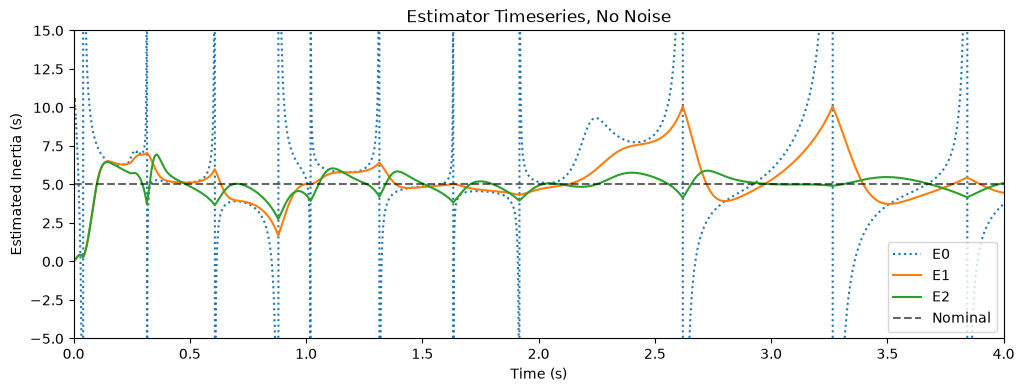

In [64]:
fig, ax = plt.subplots(figsize=(12, 4))

# color map :D
est_colors = {
    "E0":"tab:blue",
    "E1":"tab:orange",
    "E2": "tab:green"
}

# plot each estimator
for estimator in ["E0", "E1", "E2"]:
    style = ":" if (estimator == "E0") else "-" # can barely see anything with E1 in the way bro
    series = clean_est.loc[:,estimator]
    ax.plot(series.index, series, label=estimator, linestyle=style, color=est_colors[estimator])

ax.axline((0, 5), slope=0, linestyle="--", color="black", label="Nominal", alpha=0.6)
ax.legend(loc="lower right")

ax.set_ylim(-5, 15)
ax.set_xlim(0, 4)

ax.set_title("Estimator Timeseries, No Noise")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Estimated Inertia (s)")

## Run Through Estimators

In [52]:
tau_vals = [0.02,0.2]
rec_h_vals = tau_vals[::2] # record H timeseries every other value

In [53]:
runs_data = []
h_series_raw = {}

for tau in tau_vals:
        # run each estimator
        run = run_all_estimators(omega_int, power, t_est, tau, noise=None)    

        # metrics + write to dataframe          
        h_series_raw[tau] = run

        print(f"Completed runs for {tau}")#. Recording = {tf in rec_h_vals}")
#runs_data

Completed runs for 0.02
Completed runs for 0.2


In [54]:
reformed_dict = {
    (outer_key, inner_key): values 
    for outer_key, inner_dict in h_series_raw.items() 
    for inner_key, values in inner_dict.items()
}

h_timeseries = pd.DataFrame(reformed_dict, index=t_est)
h_timeseries = h_timeseries.swaplevel(axis="columns")
h_timeseries.sort_index(inplace=True)
h_timeseries

,E0,E1,E2,E0,E1,E2
,0.02,0.02,0.02,0.20,0.20,0.20
time,,,,,,
1.110223e-15,10.158637,0.000000,0.000000,101.586367,0.000000,0.000000
1.000000e-04,10.192111,0.001440,0.001440,101.464747,0.001440,0.001440
9.000000e-04,10.076913,0.013269,0.013269,96.878078,0.013283,0.013283
1.000000e-03,10.183294,0.014770,0.014770,97.499324,0.014786,0.014786
1.100000e-03,10.338125,0.016302,0.016302,98.580943,0.016320,0.016320
...,...,...,...,...,...,...
3.998100e+00,3.709804,4.464888,5.083276,-26.795955,2.328697,2.322829
3.998900e+00,3.721037,4.462566,5.085854,-27.913780,2.316074,2.302159


In [55]:
h_timeseries.columns.levels

FrozenList([['E0', 'E1', 'E2'], [0.02, 0.2]])

(-5.0, 15.0)

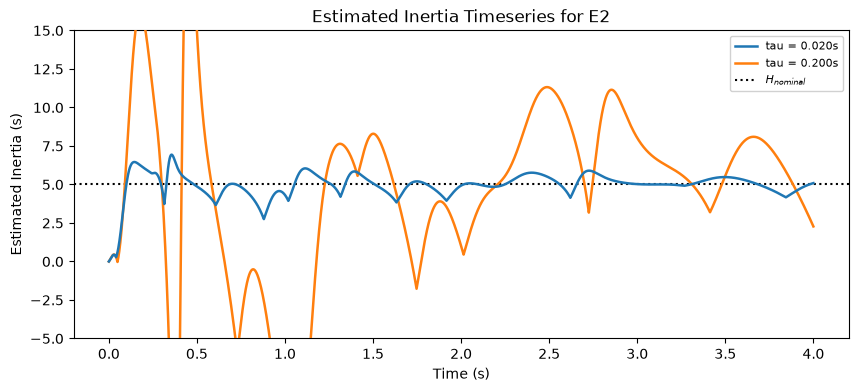

In [58]:
H_gfm = 5
estimator = "E2"
inset = False

h_timeseries_ex = h_timeseries.loc[:,estimator]

cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(10, 4))

# create an inset!
if inset:
    axins = ax.inset_axes(
        [0.6, 0.05, 0.3, 0.3],  # [x, y, width, height] w.r.t. axes
        xlim=[0.99, 1.3], ylim=[-2, 8], # sets viewport & tells relation to main axes
        xticklabels=[], yticklabels=[] )

    axins.axline((0, H_gfm), slope=0, color="black", linestyle=":")

    # add indicators for the inset
    ax.indicate_inset_zoom(axins, edgecolor="blue")
    
for i, tr_val in enumerate(h_timeseries_ex.columns):
    if (i % 1 == 0):
        ax.plot(h_timeseries_ex.index, h_timeseries_ex[tr_val],  linewidth=1.8,
                label=f"tau = {tr_val:.3f}s", zorder = 10 - i)

        if inset:
            axins.plot(h_timeseries_ex.index, h_timeseries_ex[tr_val],linewidth=1.8, zorder = 10 - i)

# nominal inertia
ax.axline((0, H_gfm), slope=0, color="black", linestyle=":", label=f"$H_{{nominal}}$")

# labels
ax.set_xlabel("Time (s)")
ax.set_ylabel("Estimated Inertia (s)")
ax.set_title(f"Estimated Inertia Timeseries for {estimator}")
ax.legend(loc="best", fontsize=8, framealpha=0.9)
#ax.set_xlim(25, 30)
ax.set_ylim(-5, 15)